In [1]:
using Plots
using Serialization

In [19]:
dir = "../../examples/ssa/runs/"

res0 = dir*"/solution_0res.jls"
x0, u_list0, H_used0, it0 = deserialize(res0)

res1 = dir*"/solution_1res.jls"
x1, u_list1, H_used1, it1 = deserialize(res1)

res2 = dir*"/solution_2res.jls"
x2, u_list2, H_used2, it2 = deserialize(res2)

res3 = dir*"/solution_3res.jls"
x3, u_list3, H_used3, it3 = deserialize(res3)

res4 = dir*"/solution_4res.jls"
x4, u_list4, H_used4, it4 = deserialize(res4)

res5 = dir*"/solution_5res.jls"
x5, u_list5, H_used5, it5 = deserialize(res5)

res6 = dir*"/solution_6res.jls"
x6, u_list6, H_used6, it6 = deserialize(res6)

(0.0:48.84004884004884:200000.0, Any[0.0:1.6718910538814958e-9:6.846393865644725e-6, [1.5854895991882293e-6, 1.5884693999351479e-6, 1.5914334431174672e-6, 1.5943821810865375e-6, 1.597316044078086e-6, 1.600235441735961e-6, 1.6031407645015388e-6, 1.6060323848831186e-6, 1.6089106586178534e-6, 1.6117759257372354e-6  …  8.725572245160627e-6, 8.727244153915441e-6, 8.728916060696735e-6, 8.730587965506228e-6, 8.73225986834563e-6, 8.733931769216651e-6, 8.735603668121e-6, 8.737275565060382e-6, 8.73894746003651e-6, 8.740619353051082e-6], [1.5854895991882293e-6, 1.589869905590826e-6, 1.5942116741503296e-6, 1.5985161416961095e-6, 1.6027844802402564e-6, 1.6070178016649487e-6, 1.611217161981056e-6, 1.615383565205084e-6, 1.6195179668955625e-6, 1.623621277384844e-6  …  8.974112190924337e-6, 8.975784110172531e-6, 8.977456026131534e-6, 8.979127938804207e-6, 8.980799848193407e-6, 8.982471754301986e-6, 8.984143657132792e-6, 8.985815556688676e-6, 8.987487452972484e-6, 8.989159345987058e-6], [1.5854895991882

In [20]:
Base.@kwdef struct constants
    rho::Float64 = 900.0 # kg m^-3
    rhow::Float64 = 1000.0 # kg m^-3
    n::Float64 = 3.0 # for Glen's law
    B::Float64 = 1.9e8 # Pa s^1/3
    g::Float64 = 9.8 # m s^-2
    secpera::Float64 = 365*24*3600 # seconds per one year
    A::Float64 = 1.4579e-25 # same as 1/B^3
end

# analytical solution
function analytical(x, cst::constants, ug, Hg, M0)
    rho = cst.rho # kg m^-3
    rhow = cst.rhow # kg m^-3
    n = cst.n # for Glen's law
    B = cst.B # Pa s^1/3
    g = cst.g # m s^-2
    
    # for convenience
    r = rho/rhow
    Cs = cst.A*(0.25*rho*g*(1-r))^n
    qg = ug*Hg

    # initiate u, H
    Nx = length(x)
    u = zeros(Nx)
    H = zeros(Nx)

    # form u, H
    for i in 1:Nx
        u[i] = ( ug^(n+1) + (Cs/M0) * ((M0 * x[i] + qg)^(n+1) - qg^(n+1)) )^(1/(n+1))
        H[i] = (M0 * x[i] + qg) / u[i];
    end

    return H, u
end

analytical (generic function with 1 method)

In [21]:
cst = constants()
# for analytical solution (and boundary condition at x=0)
ug = 50.0/cst.secpera # m/y; speed at grounding line
Hg = 500.0 # m; ice thickness at grounding line
M0 = 0.3/cst.secpera # m/y; surface mass balance

# analytical sollution
H0, u0 = analytical(x0, cst, ug, Hg, M0)
H1, u1 = analytical(x1, cst, ug, Hg, M0)
H2, u2 = analytical(x2, cst, ug, Hg, M0)
H3, u3 = analytical(x3, cst, ug, Hg, M0)
H4, u4 = analytical(x4, cst, ug, Hg, M0)
H5, u5 = analytical(x5, cst, ug, Hg, M0)
H6, u6 = analytical(x6, cst, ug, Hg, M0)

([500.0, 497.3240394296122, 494.7257091518976, 492.20117348581, 489.74686376546754, 487.35945456121135, 485.03584246208476, 482.7731270979219, 480.56859412519316, 478.4196999394227  …  279.78905540397204, 279.7887250027306, 279.7883948884749, 279.7880650609049, 279.787735519721, 279.78740626462366, 279.787077295314, 279.7867486114934, 279.78642021286356, 279.78609209912656], [1.5854895991882293e-6, 1.5949548966919353e-6, 1.6042708304531363e-6, 1.6134432004300874e-6, 1.6224774628095874e-6, 1.6313787571716185e-6, 1.6401519309923e-6, 1.648801561794408e-6, 1.657331977213425e-6, 1.6657472732118832e-6  …  9.618499207210085e-6, 9.620171148425133e-6, 9.6218430837196e-6, 9.623515013098644e-6, 9.625186936567415e-6, 9.626858854131057e-6, 9.628530765794713e-6, 9.630202671563513e-6, 9.631874571442591e-6, 9.633546465437064e-6])

In [5]:
println(maximum(H0.-H_used0))
println(maximum(H1.-H_used1))
println(maximum(H2.-H_used2))
println(maximum(H3.-H_used3))
println(maximum(H4.-H_used4))

0.0
0.0
0.0
0.0
0.0


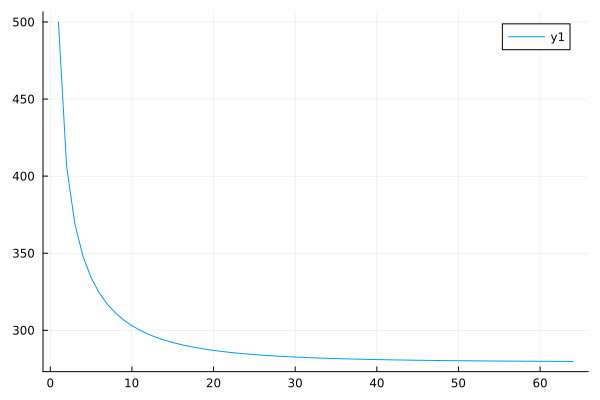

In [6]:
plot(H0)

0.0


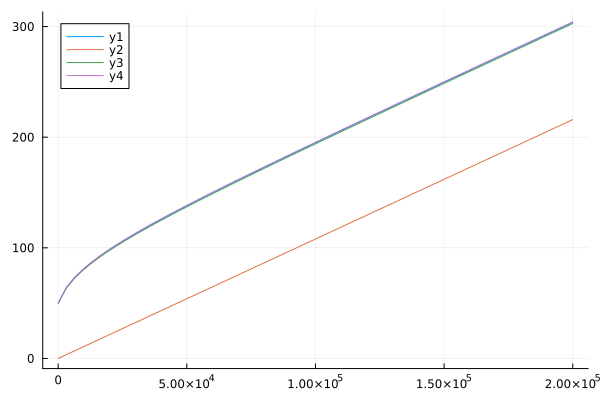

In [7]:
err0 = u0.-u_list0[end];
println(maximum(err0)*cst.secpera)

plot(x0,u0*cst.secpera)
plot!(x0, u_list0[1]*cst.secpera)
plot!(x0, u_list0[10]*cst.secpera)
plot!(x0, u_list0[end]*cst.secpera)

0.0


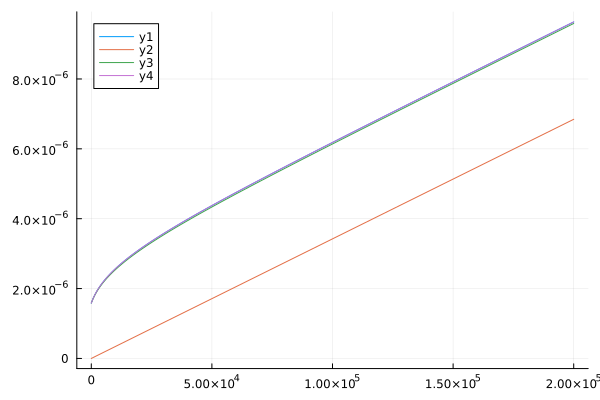

In [8]:
err2 = u2.-u_list2[end];
println(maximum(err2)*cst.secpera)

plot(x2,u2)
plot!(x2, u_list2[1])
plot!(x2, u_list2[10])
plot!(x2, u_list2[end])

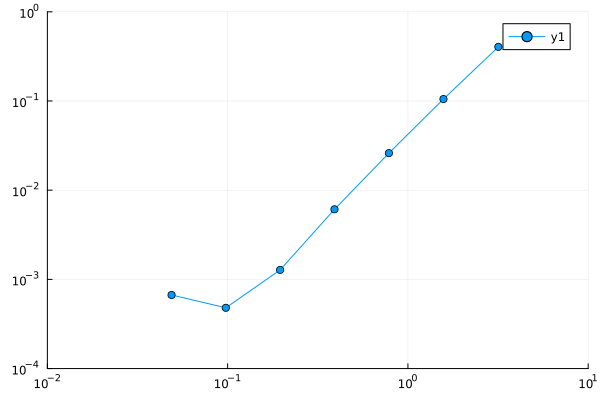

In [22]:
function err(f1, f2)
    return maximum(abs.(f1-f2))
end

err0 = err(u0, u_list0[end])
err1 = err(u1, u_list1[end])
err2 = err(u2, u_list2[end])
err3 = err(u3, u_list3[end])
err4 = err(u4, u_list4[end])
err5 = err(u5, u_list5[end])
err6 = err(u6, u_list6[end])

errs = [err0, err1, err2, err3, err4, err5, err6]
dxs = [x0[2]-x0[1], x1[2]-x1[1], x2[2]-x2[1], x3[2]-x3[1], x4[2]-x4[1],
    x5[2]-x5[1], x6[2]-x6[1]]

plot(dxs/1000, errs*cst.secpera,
    xscale = :log10,
    yscale = :log10,
    marker = :circle,
    markersize = 4,
    xlim=(1.0e-2,10.0),
    ylim=(1.0e-4,1.0)
    )

In [23]:
dxs

7-element Vector{Float64}:
 3174.6031746031745
 1574.8031496062993
  784.3137254901961
  391.3894324853229
  195.50342130987292
   97.70395701025892
   48.84004884004884

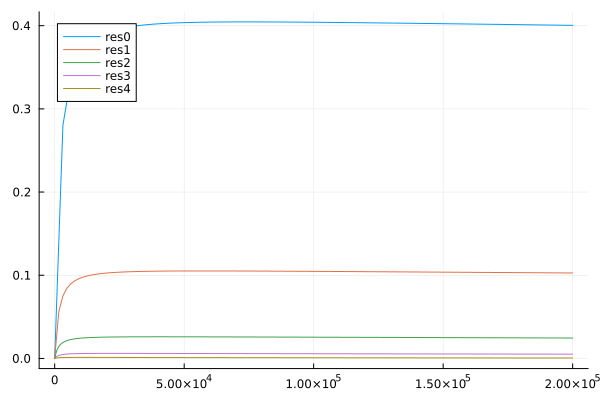

In [17]:
plot(x0, cst.secpera*abs.(u0-u_list0[end]), label="res0")
plot!(x1, cst.secpera*abs.(u1-u_list1[end]), label="res1")
plot!(x2, cst.secpera*abs.(u2-u_list2[end]), label="res2")
plot!(x3, cst.secpera*abs.(u3-u_list3[end]), label="res3")
plot!(x4, cst.secpera*abs.(u4-u_list4[end]), label="res4")